# Can engaged vs disengaged trials be told apart from syllable use?

Companion to `transition_prediction.ipynb`: same data, models and tests (`tp_data.py`, `tp_models.py`), but the target is the **state on trial t** (`disengaged` = most probable K=2 state is not the engaged one), not the switch into it.

Two questions, run as two modes:

* **`predictive`** — can the state be told *before the stimulus*? Inputs: trial t's Pre-quiescence + Quiescence and trials t-1 … t-`LAG`. Baseline: task history of t-1 … t-`LAG` and position in session.
* **`concurrent`** — do engaged and disengaged trials *look* different, beyond their outcome? Inputs: all four epochs of trial t plus the past. Baseline adds trial t's own reward, |contrast| and block-congruent choice, because trial t's Choice/ITI syllables carry the outcome (rewarded trials are followed by licking) and disengaged trials are mostly errors.

Design notes:

* **No state history in the baseline.** Dwell time (used for transitions) is dropped: long dwells are engaged dwells, so it would hand the model the previous state, and states last tens of trials.
* **Session-centred syllables** (`CENTER='session'`): only trial-to-trial fluctuations; session-level usage is what LD1 is built from.
* **Mice held out** in every fold. Pooled AUC mixes sessions with different disengagement rates, so the **median within-session AUC** is reported too: does the model rank a session's own disengaged trials above its engaged ones?
* The state label comes from a model fit to choices, and the smoothed posterior on trial t also uses choices at t+1, t+2, … — so "predicting the state" is partly predicting upcoming choices.

In [1]:
import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
sys.path.insert(0, str(_p / 'GLM-HMM' / 'transition_prediction'))
import paper_style as ps
import tp_data as td
import tp_models as tm
ps.use('paper')
pd.set_option('display.width', 160)

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


## Parameters

In [2]:
STATE_SOURCE = 'k2_original'   # 'k2_original' or 'all_k'
K = 2                          # only with 'all_k'
FEATURE_SET = 'decomposed'     # 'decomposed' or 'joint'
EPOCHS = td.EPOCHS
LAG_MODE = 'stack'
CENTER = 'session'

TARGET = 'disengaged'
MODES = ['predictive', 'concurrent']
LAGS = [0, 1, 2, 3, 5]         # trials back (0 = trial t only)
MODE = 'predictive'            # mode for sections 3 and 4
LAG = 2                        # lag for sections 3 and 4 (revisit after the sweep)
CV = 'mouse'
N_SPLITS = 5
N_LD1_BINS = 3
MIN_EVENTS_SESSION = 10        # disengaged trials a session needs for a within-session AUC

DESIGN_KW = dict(epochs=EPOCHS, lag_mode=LAG_MODE, center=CENTER)

## 1. Data

In [3]:
df = td.build_trial_table(STATE_SOURCE, K, FEATURE_SET)
print(f"{df['eid'].nunique()} sessions, {df['mouse_name'].nunique()} mice, {len(df)} trials; "
      f"disengaged on {df['disengaged'].mean():.1%} of trials")
sess = df.groupby('eid')['disengaged'].agg(['mean', 'sum'])
print(f"sessions with >= {MIN_EVENTS_SESSION} disengaged trials: {(sess['sum'] >= MIN_EVENTS_SESSION).sum()} / {len(sess)}")
sess['mean'].describe().round(3)

244 sessions, 56 mice, 152377 trials; disengaged on 13.2% of trials
sessions with >= 10 disengaged trials: 224 / 244


count    244.000
mean       0.136
std        0.142
min        0.000
25%        0.040
50%        0.083
75%        0.190
max        0.728
Name: mean, dtype: float64

### 1b. Model-free: how do disengaged trials differ, epoch by epoch?
Per mouse: mean session-centred usage on disengaged minus engaged trials (trial t's own epochs), then the median across mice; stars = Wilcoxon across mice, FDR-corrected. Choice and ITI differences are partly the outcome (errors) — that is what the `concurrent` baseline controls for.

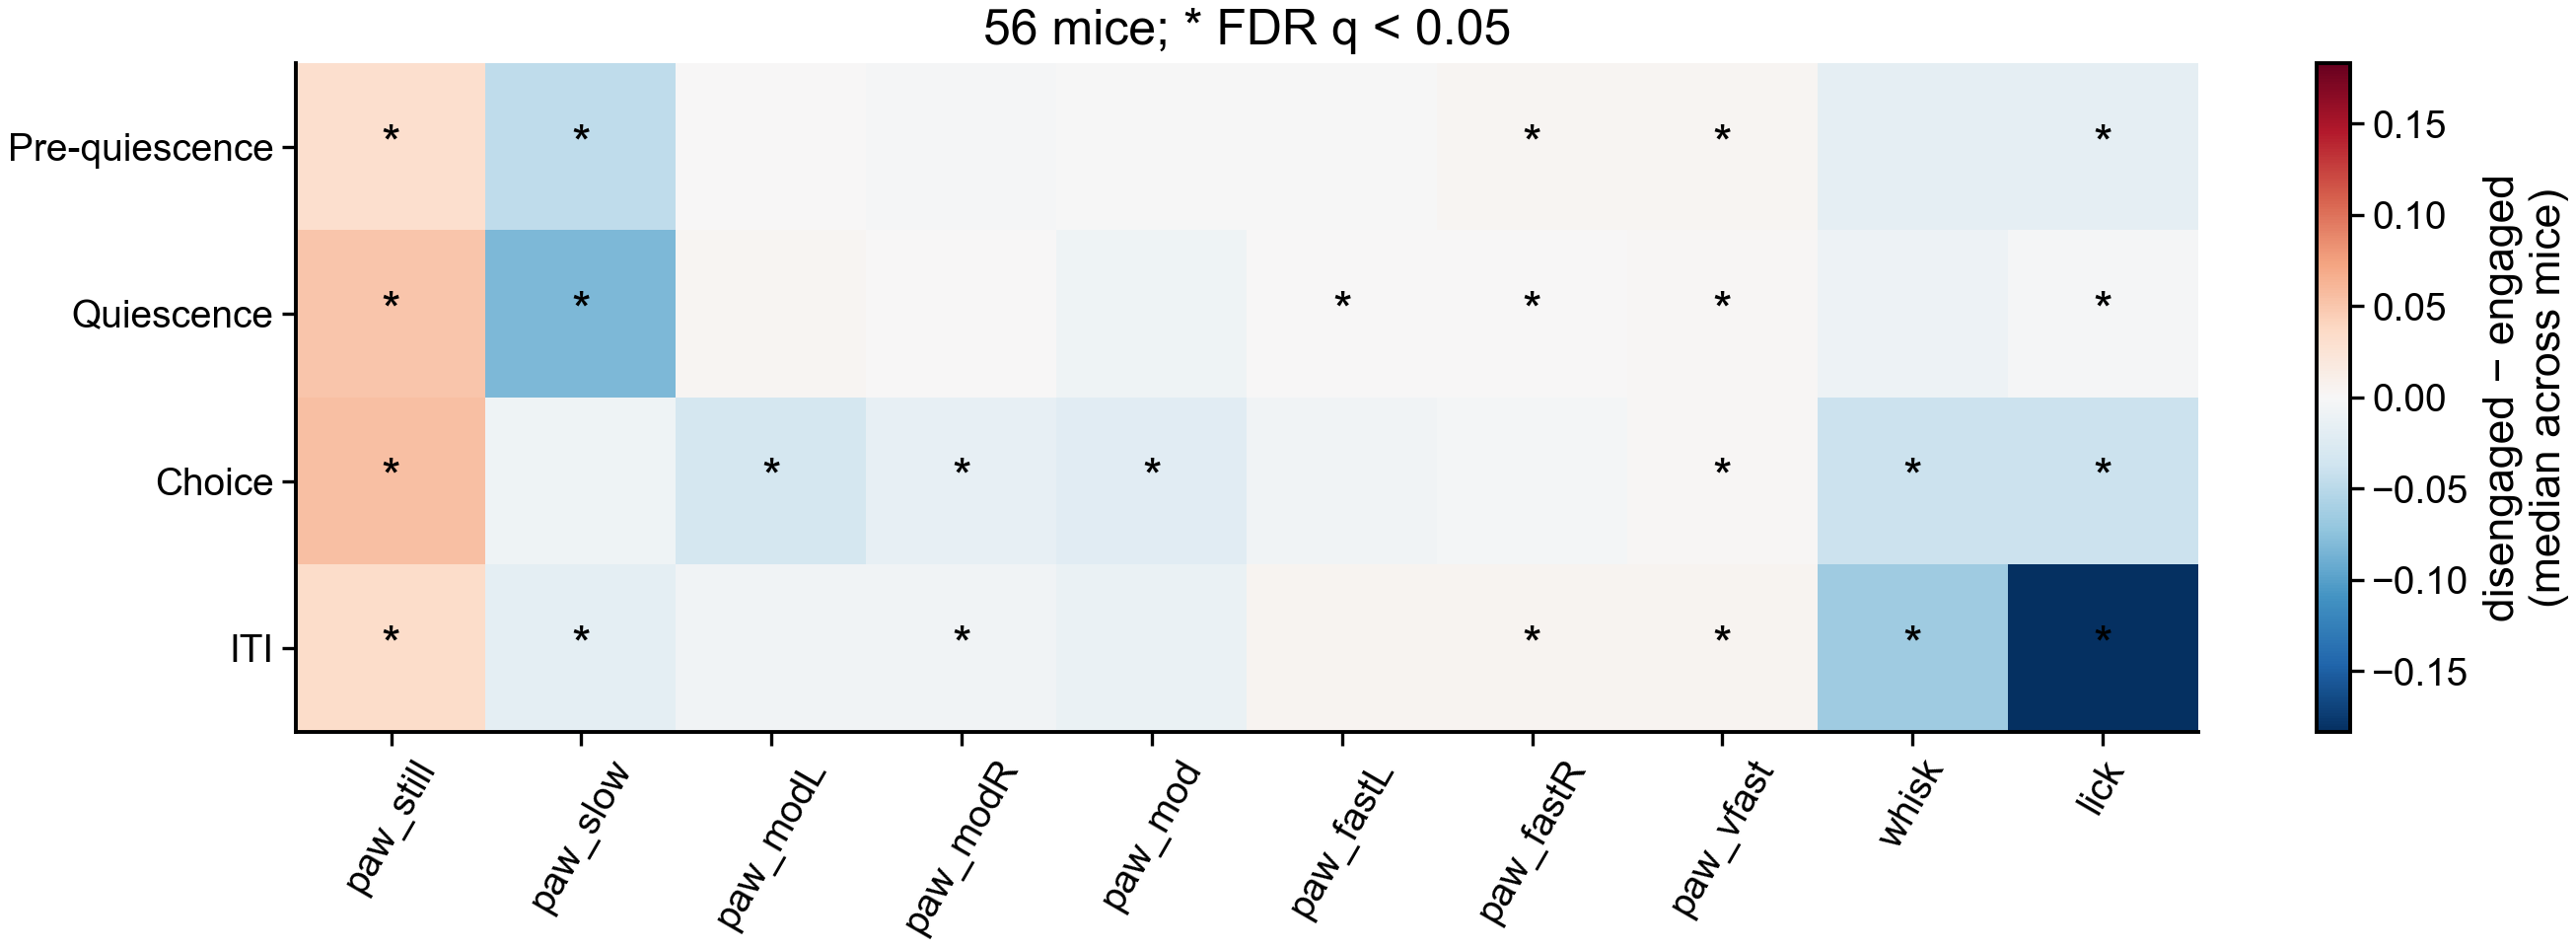

In [4]:
from statsmodels.stats.multitest import multipletests
cols = td.syllable_columns(df)
Xc = df[cols] - df[cols].groupby(df['eid']).transform('mean')
diff = (Xc[df['disengaged'] == 1].groupby(df['mouse_name']).mean()
        - Xc[df['disengaged'] == 0].groupby(df['mouse_name']).mean()).dropna()
p = np.array([wilcoxon(diff[c]).pvalue for c in cols])
q = multipletests(p, method='fdr_bh')[1]
med = diff.median()
feats = list(dict.fromkeys(c.split('|')[1] for c in cols))
M = pd.DataFrame([[med[f'{e}|{f}'] for f in feats] for e in td.EPOCHS], index=td.EPOCHS, columns=feats)
Q = pd.DataFrame([[q[cols.index(f'{e}|{f}')] for f in feats] for e in td.EPOCHS], index=td.EPOCHS, columns=feats)
v = np.abs(M.values).max()
fig, ax = plt.subplots(figsize=(7, 2.6))
im = ax.imshow(M.values, cmap='RdBu_r', vmin=-v, vmax=v, aspect='auto')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if Q.iat[i, j] < 0.05:
            ax.text(j, i, '*', ha='center', va='center', fontsize=9)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=60)
ax.set_yticks(range(4)); ax.set_yticklabels(td.EPOCHS)
fig.colorbar(im, ax=ax, label='disengaged − engaged\n(median across mice)')
ax.set_title(f'{len(diff)} mice; * FDR q < 0.05')
fig.tight_layout(); plt.show()

## 2. How well can the state be predicted, and how far back does it help to look?

In [5]:
def within_session(y, preds, meta):
    pu = tm.per_unit_scores(y, preds, meta, unit='eid', min_events=MIN_EVENTS_SESSION)
    return {f'{m}_auc_within': pu[f'{m}_auc'].median() for m in ['base', 'syll', 'full']}

rows = []
for mode in MODES:
    for lag in LAGS:
        Xb, Xs, y, meta = td.design(df, TARGET, lag=lag, mode=mode, **DESIGN_KW)
        summ, preds, _ = tm.compare_models(Xb, Xs, y, meta, cv=CV, n_splits=N_SPLITS)
        ws = within_session(y, preds, meta)
        for r in summ.itertuples():
            rows.append(dict(mode=mode, lag=lag, model=r.model, n_features=r.n_features, auc=r.auc,
                             ap=r.ap, ll_skill=r.ll_skill, base_rate=r.base_rate,
                             auc_within=ws[f'{r.model}_auc_within']))
        print(f"{mode} lag {lag}: " + ', '.join(f"{r.model} skill={r.ll_skill:.3f} auc={r.auc:.3f}"
                                               for r in summ.itertuples()), flush=True)
sweep_df = pd.DataFrame(rows)
sweep_df.to_csv(td.HERE / f'results_state_sweep_{STATE_SOURCE}_K{K}.csv', index=False)
sweep_df.pivot_table(index=['mode', 'lag'], columns='model', values=['ll_skill', 'auc', 'auc_within']).round(3)

predictive lag 0: base skill=0.005 auc=0.555, syll skill=0.006 auc=0.547, full skill=0.009 auc=0.565


predictive lag 1: base skill=0.030 auc=0.615, syll skill=0.020 auc=0.592, full skill=0.039 auc=0.631


predictive lag 2: base skill=0.044 auc=0.643, syll skill=0.026 auc=0.604, full skill=0.054 auc=0.659


predictive lag 3: base skill=0.053 auc=0.655, syll skill=0.029 auc=0.607, full skill=0.064 auc=0.672


predictive lag 5: base skill=0.066 auc=0.676, syll skill=0.031 auc=0.612, full skill=0.076 auc=0.689


...

concurrent lag 1: base skill=0.081 auc=0.691, syll skill=0.037 auc=0.631, full skill=0.090 auc=0.703


concurrent lag 2: base skill=0.093 auc=0.709, syll skill=0.041 auc=0.636, full skill=0.102 auc=0.720


concurrent lag 3: base skill=0.101 auc=0.717, syll skill=0.043 auc=0.637, full skill=0.111 auc=0.728


concurrent lag 5: base skill=0.112 auc=0.731, syll skill=0.045 auc=0.640, full skill=0.121 auc=0.740


auc               auc_within               ll_skill              
model            base   full   syll       base   full   syll     base   full   syll
mode       lag                                                                     
concurrent 0    0.652  0.665  0.615      0.692  0.706  0.671    0.059  0.066  0.029
           1    0.691  0.703  0.631      0.744  0.756  0.688    0.081  0.090  0.037
           2    0.709  0.720  0.636      0.766  0.768  0.689    0.093  0.102  0.041
           3    0.717  0.728  0.637      0.774  0.782  0.691    0.101  0.111  0.043
           5    0.731  0.740  0.640      0.781  0.791  0.694    0.112  0.121  0.045
predictive 0    0.555  0.565  0.547      0.568  0.588  0.567    0.005  0.009  0.006
           1    0.615  0.631  0.592      0.616  0.634  0.609    0.030  0.039  0.020
           2    0.643  0.659  0.604      0.643  0.658  0.620    0.044  0.054  0.026
           3    0.655  0.672  0.607      0.656  0.669  0.624    0.053  0.064  0.029
           5    0.676  0.689  0.612      0.667  0.678  0.627    0.066  0.076  0.031

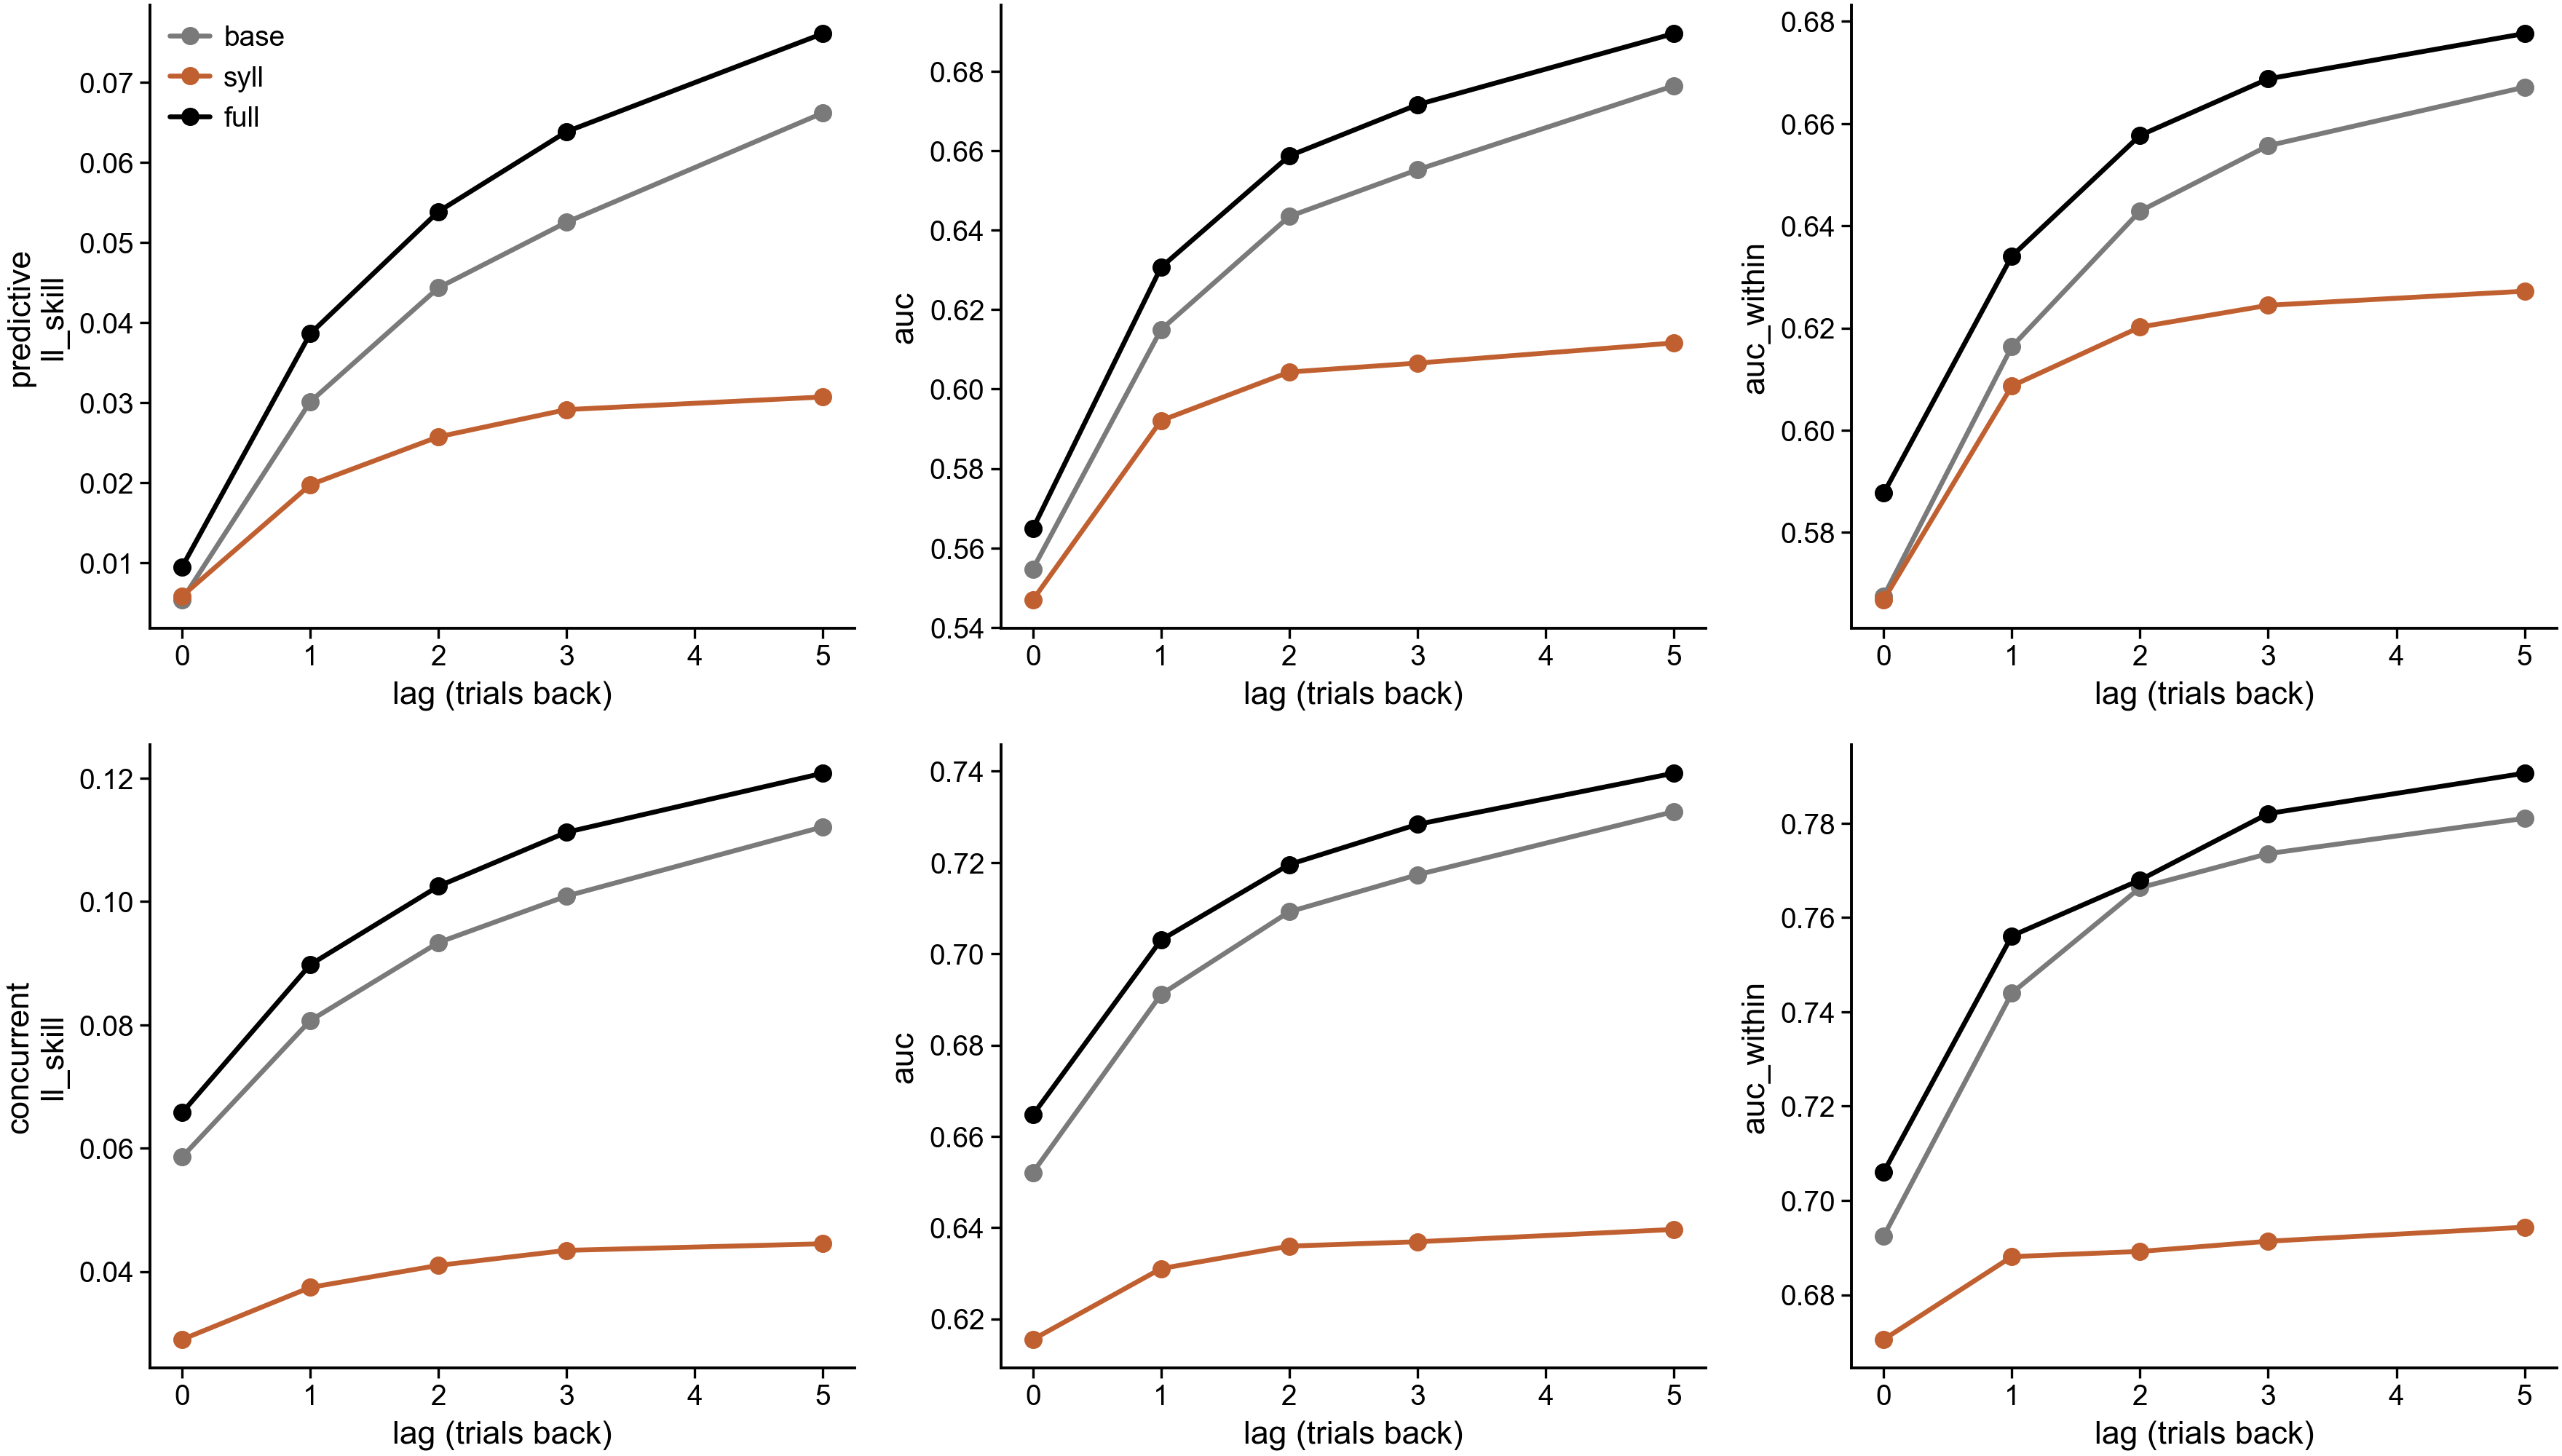

In [6]:
colors = {'base': ps.NEUTRAL, 'syll': '#c06030', 'full': 'k'}
fig, axes = plt.subplots(len(MODES), 3, figsize=(9, 2.6 * len(MODES)), squeeze=False)
for row, mode in enumerate(MODES):
    s = sweep_df[sweep_df['mode'] == mode]
    for col, metric in enumerate(['ll_skill', 'auc', 'auc_within']):
        for m in ['base', 'syll', 'full']:
            d = s[s['model'] == m]
            axes[row, col].plot(d['lag'], d[metric], 'o-', color=colors[m], label=m)
        axes[row, col].set_xlabel('lag (trials back)')
        axes[row, col].set_ylabel(f'{mode}\n{metric}' if col == 0 else metric)
axes[0, 0].legend(frameon=False)
fig.tight_layout(); plt.show()

## 3. What does the prediction rely on? (`MODE`, `LAG`)

In [7]:
Xb, Xs, y, meta = td.design(df, TARGET, lag=LAG, mode=MODE, **DESIGN_KW)
summary, preds, folds = tm.compare_models(Xb, Xs, y, meta, cv=CV, n_splits=N_SPLITS)
print(f'{TARGET}, {MODE}, lag {LAG}: {y.sum()} disengaged / {len(y)} trials')
print(within_session(y, preds, meta))
summary.round(4)

disengaged, predictive, lag 2: 19918 disengaged / 151889 trials


{'base_auc_within': 0.642874367012298, 'syll_auc_within': 0.6201846842645276, 'full_auc_within': 0.6576795099045308}


,model,n_features,n,events,base_rate,auc,ap,logloss,ll_skill
0,base,7,151889,19918,0.1311,0.6434,0.2377,0.3716,0.0444
1,syll,100,151889,19918,0.1311,0.6043,0.2080,0.3789,0.0257
2,full,107,151889,19918,0.1311,0.6587,0.2517,0.3679,0.0539


baseline terms (standardised):
                   mean     sd  sign_agreement
trial_frac        0.201  0.053             1.0
reward_t-1       -0.470  0.013             1.0
abs_contrast_t-1  0.105  0.012             1.0
congruent_t-1     0.130  0.022             1.0
reward_t-2       -0.358  0.013             1.0
abs_contrast_t-2  0.075  0.008             1.0
congruent_t-2     0.121  0.021             1.0

largest syllable weights, same sign in every fold (+ = more likely disengaged):
                          mean     sd  sign_agreement
t-1|ITI|whisk            0.096  0.010             1.0
t-2|ITI|whisk            0.096  0.011             1.0
t-2|Choice|lick         -0.089  0.014             1.0
t|Quiescence|paw_modL    0.076  0.007             1.0
t-1|Choice|lick         -0.074  0.016             1.0
t|Quiescence|paw_slow   -0.071  0.005             1.0
t-1|ITI|lick             0.060  0.019             1.0
t-2|Choice|paw_still     0.057  0.011             1.0
t-1|Choice|paw_still     0

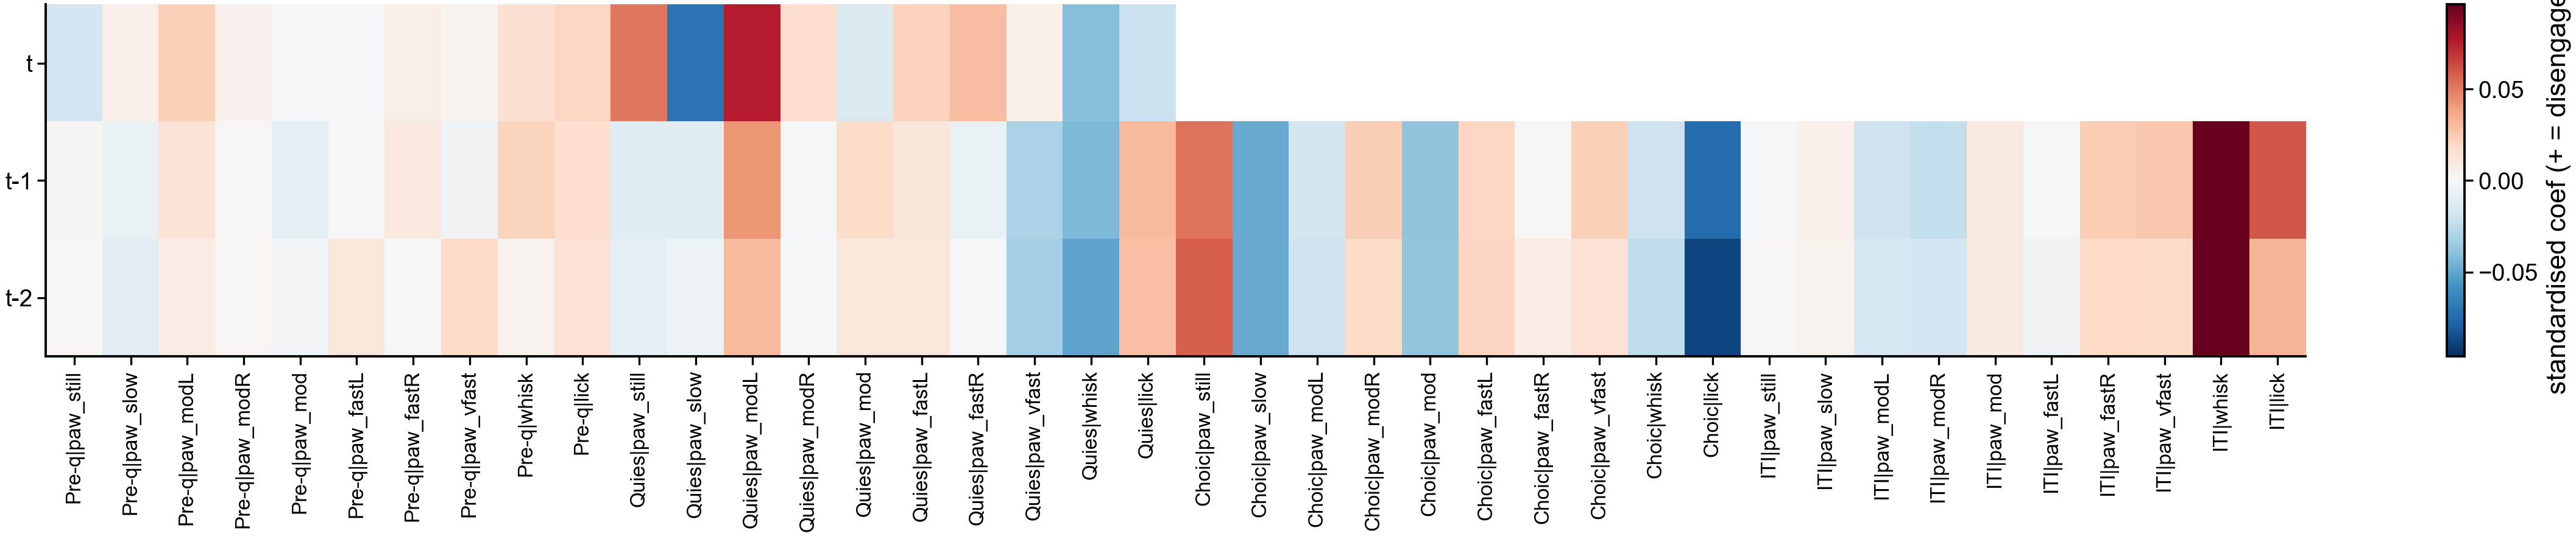

In [8]:
Xfull = pd.concat([Xb, Xs], axis=1)
coef = tm.coefficients(folds['full'], Xfull.columns)
print('baseline terms (standardised):'); print(coef.loc[Xb.columns].round(3))
print('\nlargest syllable weights, same sign in every fold (+ = more likely disengaged):')
cs = coef.loc[Xs.columns]
print(cs[cs['sign_agreement'] == 1].reindex(cs['mean'].abs().sort_values(ascending=False).index).dropna().head(15).round(3))

parts = cs.index.str.split('|', expand=True)
H = pd.Series(cs['mean'].values, index=pd.MultiIndex.from_tuples(parts, names=['lag', 'epoch', 'feature'])).unstack(['epoch', 'feature'])
order = ['t'] + [f't-{l}' for l in range(1, LAG + 1)] if LAG_MODE == 'stack' else list(H.index)
H = H.reindex([o for o in order if o in H.index])
H = H[[c for ep in td.EPOCHS for c in H.columns if c[0] == ep]]
v = np.nanmax(np.abs(H.values))
fig, ax = plt.subplots(figsize=(12, 0.4 * len(H) + 1.2))
im = ax.imshow(H.values, cmap='RdBu_r', vmin=-v, vmax=v, aspect='auto')
ax.set_yticks(range(len(H))); ax.set_yticklabels(H.index)
ax.set_xticks(range(H.shape[1])); ax.set_xticklabels([f'{e[:5]}|{f}' for e, f in H.columns], rotation=90, fontsize=6)
fig.colorbar(im, ax=ax, label='standardised coef (+ = disengaged)')
fig.tight_layout(); plt.show()


=== by ('lag',)  (Δ held-out log loss × 1e3 when shuffled within session)
group  n_cols  d_logloss_x1e3    sd
  t-1      40           3.461 0.106
  t-2      40           3.201 0.124
    t      20           2.138 0.091

=== by ('epoch',)  (Δ held-out log loss × 1e3 when shuffled within session)
         group  n_cols  d_logloss_x1e3    sd
        Choice      20           4.309 0.108
           ITI      20           4.230 0.038
    Quiescence      30           3.413 0.056
Pre-quiescence      30           0.500 0.029

=== by ('modality',)  (Δ held-out log loss × 1e3 when shuffled within session)
group  n_cols  d_logloss_x1e3    sd
  paw      80           5.386 0.168
whisk      10           2.597 0.068
 lick      10           1.306 0.136

=== by ('epoch', 'modality')  (Δ held-out log loss × 1e3 when shuffled within session)
                 group  n_cols  d_logloss_x1e3    sd
      Quiescence / paw      24           2.932 0.108
           ITI / whisk       2           2.286 0.010
        

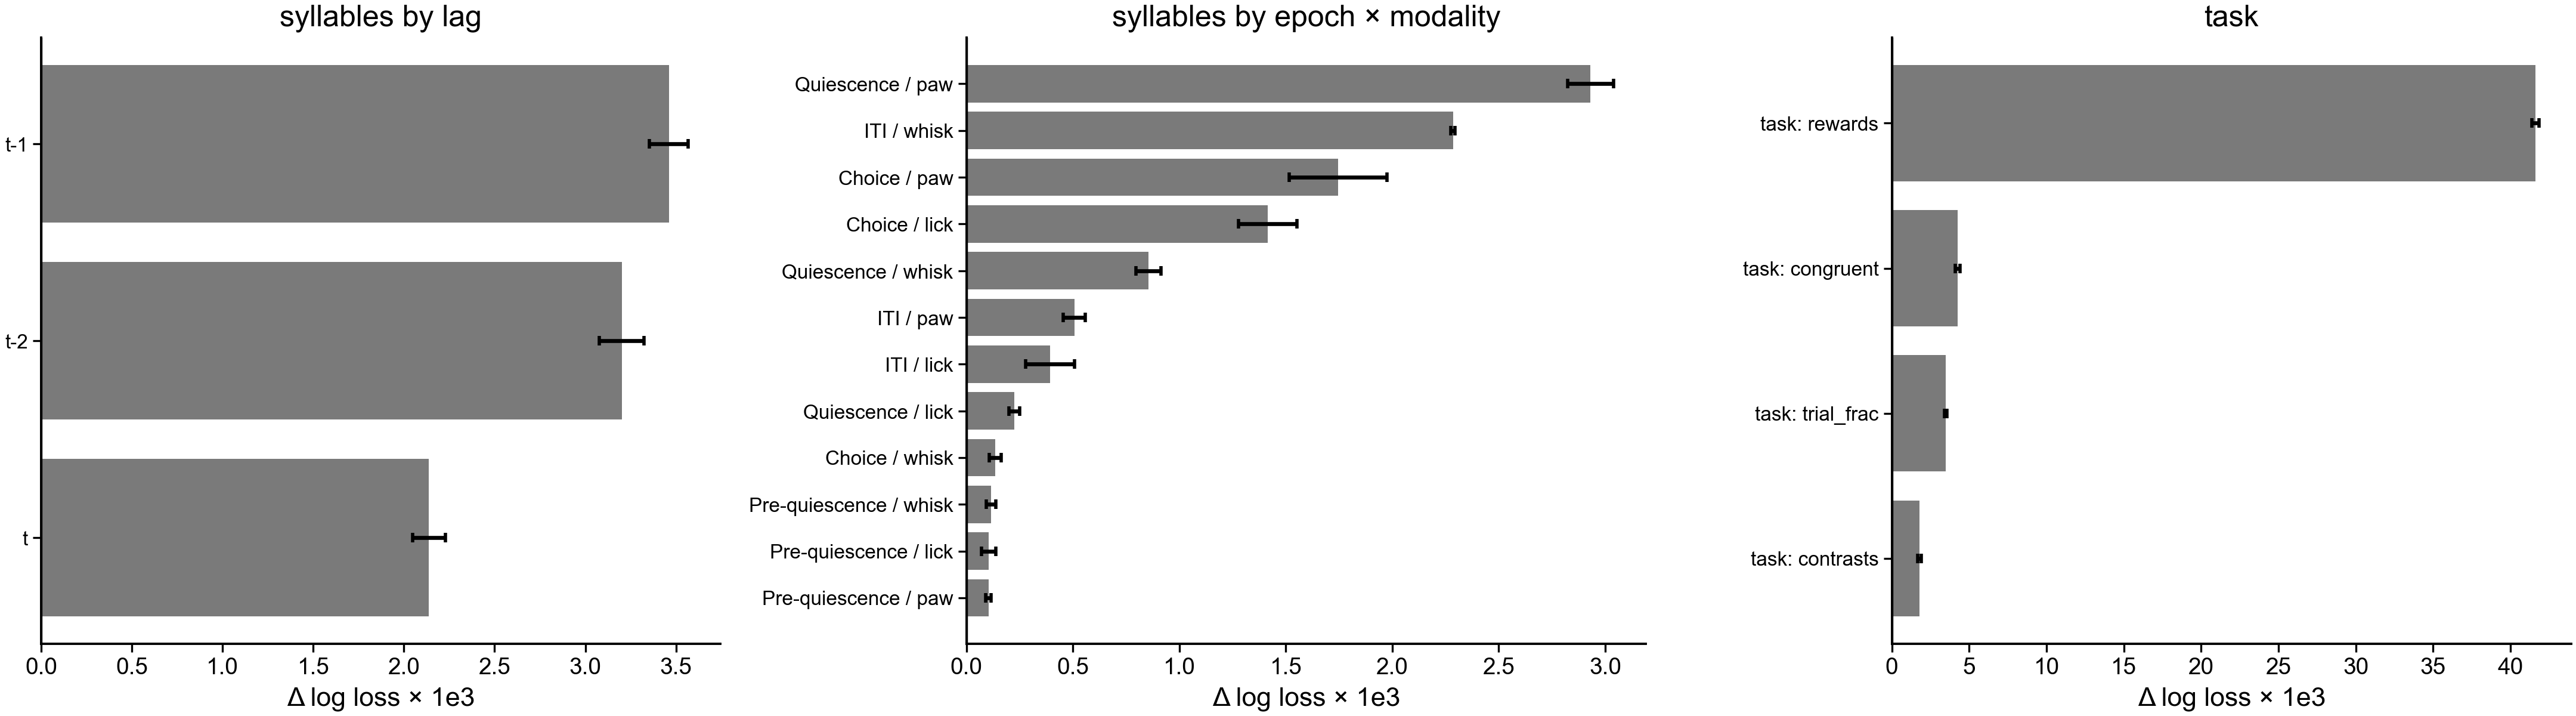

In [9]:
imp = {}
for by in [('lag',), ('epoch',), ('modality',), ('epoch', 'modality'), ('feature',)]:
    imp[by] = tm.group_importance(Xfull, y, meta, folds['full'], td.feature_groups(Xs.columns, by=by), n_repeats=3)
base_groups = {'task: rewards': [c for c in Xb.columns if c.startswith('reward')],
               'task: contrasts': [c for c in Xb.columns if c.startswith('abs_contrast')],
               'task: congruent': [c for c in Xb.columns if c.startswith('congruent')],
               'task: trial_frac': ['trial_frac']}
imp['task'] = tm.group_importance(Xfull, y, meta, folds['full'], base_groups, n_repeats=3)
for k, v in imp.items():
    print(f'\n=== by {k}  (Δ held-out log loss × 1e3 when shuffled within session)')
    print(v.head(12).round(3).to_string(index=False))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, key, title in zip(axes, [('lag',), ('epoch', 'modality'), 'task'],
                          ['syllables by lag', 'syllables by epoch × modality', 'task']):
    d = imp[key].iloc[::-1]
    ax.barh(d['group'], d['d_logloss_x1e3'], xerr=d['sd'], color=ps.NEUTRAL)
    ax.axvline(0, color='k', lw=0.8); ax.set_title(title); ax.set_xlabel('Δ log loss × 1e3')
    ax.tick_params(axis='y', labelsize=6)
fig.tight_layout(); plt.show()

## 4. Does it change along LD1?
Same three views as for transitions: per-mouse gain vs LD1, an LD1-interaction model, and transfer across LD1 terciles of mice. LD1 is lab-confounded; re-check anything positive with lab-centred LD1.

53 mice with >= 20 disengaged trials
    metric  n     rho      p
base_skill 53  0.2140 0.1239
full_skill 53  0.2217 0.1107
gain_skill 53 -0.0930 0.5079
  base_auc 53  0.1865 0.1812
  full_auc 53  0.1580 0.2586
  gain_auc 53 -0.1436 0.3050


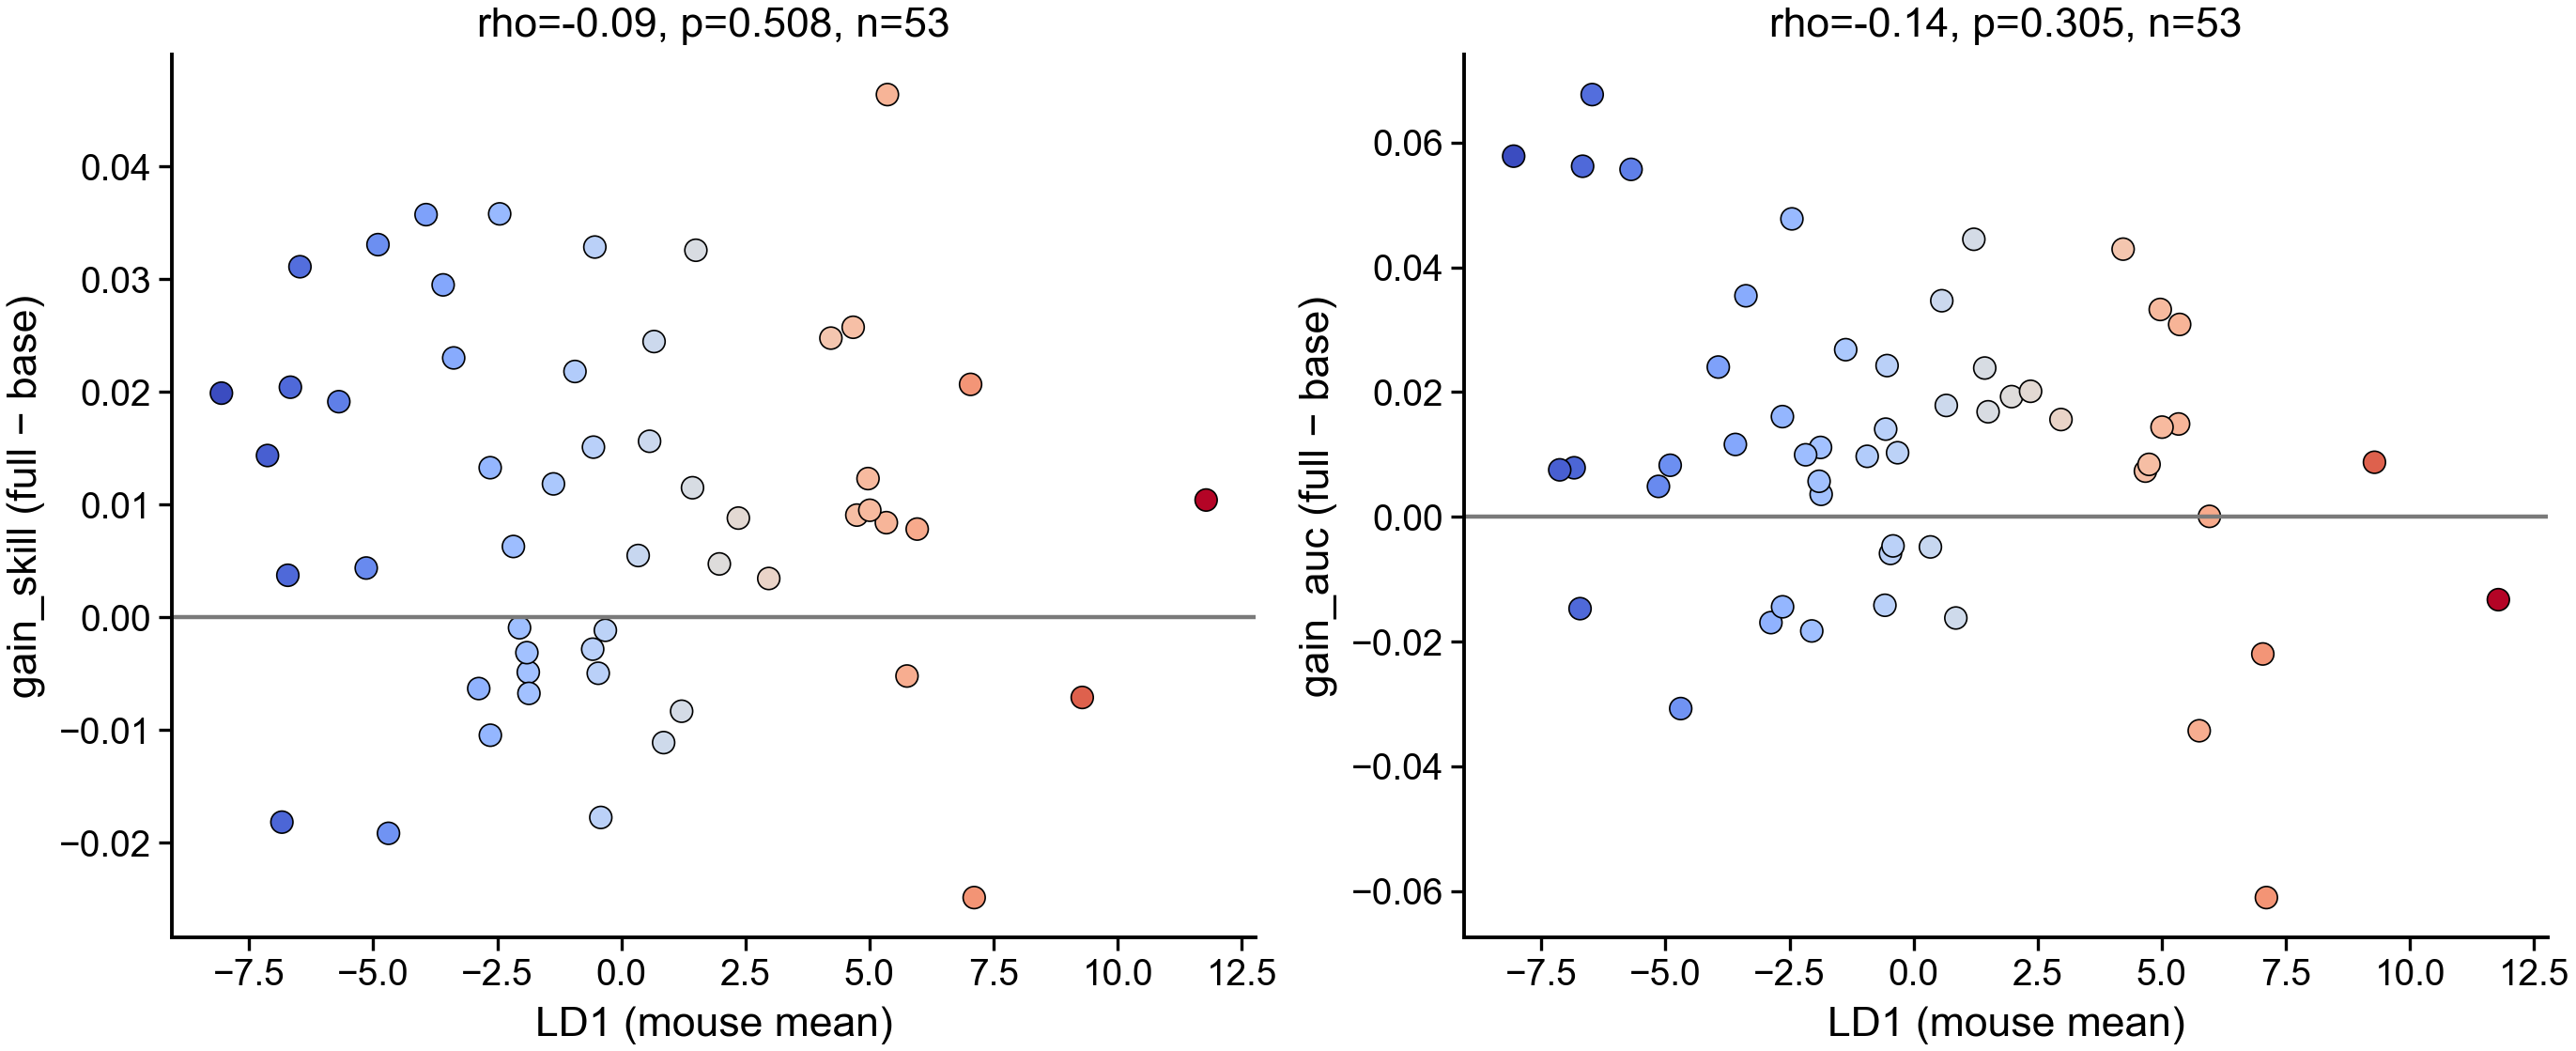

In [10]:
pm = tm.per_unit_scores(y, preds, meta, unit='mouse_name', min_events=20)
print(f'{len(pm)} mice with >= 20 disengaged trials')
print(pd.DataFrame([tm.ld1_correlation(pm, c) for c in
                    ['base_skill', 'full_skill', 'gain_skill', 'base_auc', 'full_auc', 'gain_auc']]).round(4).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, col in zip(axes, ['gain_skill', 'gain_auc']):
    ax.scatter(pm['lda_1'], pm[col], c=pm['lda_1'], cmap=ps.LD1_CMAP, s=18, edgecolor='k', lw=0.3)
    ax.axhline(0, color=ps.NEUTRAL, lw=0.8)
    r = tm.ld1_correlation(pm, col)
    ax.set_title(f"rho={r['rho']:.2f}, p={r['p']:.3f}, n={r['n']}", fontsize=8)
    ax.set_xlabel('LD1 (mouse mean)'); ax.set_ylabel(f'{col} (full − base)')
fig.tight_layout(); plt.show()

In [11]:
inter_summary, inter_mouse, inter_coefs = tm.ld1_interaction(Xb, Xs, y, meta, cv=CV, n_splits=N_SPLITS)
print(pd.DataFrame({k: inter_summary[k] for k in ['full', 'with_ld1_interaction']}).T[['auc', 'll_skill']].round(4))
print(f"\nper mouse Δ log loss (interaction − full): median {inter_summary['median_mouse_d_logloss']:.5f}, "
      f"{inter_summary['frac_mice_improved']:.0%} of mice improved, Wilcoxon p = {inter_summary['wilcoxon_p']:.3g}")
print('\nlargest (syllable × LD1) weights, same sign in every fold:')
print(inter_coefs[inter_coefs['sign_agreement'] == 1].reindex(
    inter_coefs['mean'].abs().sort_values(ascending=False).index).dropna().head(12).round(3))

                         auc  ll_skill
full                  0.6587    0.0539
with_ld1_interaction  0.6431    0.0445

per mouse Δ log loss (interaction − full): median 0.00117, 38% of mice improved, Wilcoxon p = 0.00995

largest (syllable × LD1) weights, same sign in every fold:
                                     mean     sd  sign_agreement
t-1|Choice|paw_fastR x LD1          0.031  0.011             1.0
t-1|ITI|paw_fastR x LD1            -0.025  0.003             1.0
t-2|Choice|paw_fastR x LD1          0.022  0.012             1.0
t-1|Choice|whisk x LD1             -0.021  0.009             1.0
t|Pre-quiescence|paw_modR x LD1     0.020  0.004             1.0
t-1|Pre-quiescence|paw_vfast x LD1  0.020  0.006             1.0
t-2|ITI|paw_fastR x LD1            -0.019  0.004             1.0
t-2|Choice|whisk x LD1             -0.019  0.010             1.0
t-1|Quiescence|lick x LD1           0.018  0.011             1.0
t-2|ITI|paw_slow x LD1              0.016  0.006             1.0
t|Qui

In [12]:
skill_T, auc_T, bin_coefs = tm.transfer_matrix(Xb, Xs, y, meta, n_bins=N_LD1_BINS, n_splits=N_SPLITS)
print('held-out log-loss skill (rows = trained on, cols = tested on):'); print(skill_T.round(4))
print('\nheld-out AUC:'); print(auc_T.round(3))
syl_rows = [c for c in bin_coefs.index if '|' in c]
print('\ncorrelation of syllable weights between LD1 bins:'); print(bin_coefs.loc[syl_rows].corr().round(2))

held-out log-loss skill (rows = trained on, cols = tested on):
             test bin 0  test bin 1  test bin 2
train bin 0      0.0480      0.0314      0.0556
train bin 1      0.0625      0.0172      0.0703
train bin 2      0.0554      0.0394      0.0571

held-out AUC:
             test bin 0  test bin 1  test bin 2
train bin 0       0.633       0.620       0.664
train bin 1       0.667       0.574       0.688
train bin 2       0.660       0.638       0.652

correlation of syllable weights between LD1 bins:
           LD1 bin 0  LD1 bin 1  LD1 bin 2
LD1 bin 0       1.00       0.55       0.58
LD1 bin 1       0.55       1.00       0.50
LD1 bin 2       0.58       0.50       1.00
